In [27]:
import os
import csv
import pandas
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import linregress



In [2]:
offsides_v1 = pandas.read_csv('../data/OFFSIDES.csv.gz')

/tmp/ipykernel_227669/2299837975.py:1: DtypeWarning: Columns (0,2,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  offsides_v1 = pandas.read_csv('../data/OFFSIDES.csv.gz')


In [3]:
offsides_v1.head()

,drug_rxnorn_id,drug_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
0,4024,"ergoloid mesylates, USP",10002034,Anaemia,6,126,21,1299,2.85714,0.45382,0.045455
1,4024,"ergoloid mesylates, USP",10002965,Aplasia pure red cell,1,131,1,1319,10.0,1.41126,0.007576
2,4024,"ergoloid mesylates, USP",10013442,Disseminated intravascular coagulation,1,131,6,1314,1.66667,1.07626,0.007576
3,4024,"ergoloid mesylates, USP",10023126,Jaundice,2,130,7,1313,2.85714,0.79657,0.015152
4,4024,"ergoloid mesylates, USP",10016288,Febrile neutropenia,1,131,5,1315,2.0,1.09163,0.007576


In [20]:
offsides_v2 = pandas.read_csv('../results/2004-2009/hdpsm_nrep10_mratio5_maxsamp50000_drug_reaction_associations.csv')
offsides_v2 = offsides_v2[offsides_v2['replicate'] == 0]

In [21]:
offsides_v2.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI
0,anidulafungin,RESPIRATORY FAILURE,All,0,5,31,5,174,5.612903,4.972222,0.196721,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247
10,olmesartan,CARDIOMEGALY,All,0,5,2559,33,9826,0.581785,0.582601,-0.010239,22.0,5588.0,3071.0,1588847.0,2.036895,2.032828,0.002681
11,olmesartan,PRODUCT QUALITY ISSUE,All,0,8,2556,68,9791,0.450658,0.452372,-0.019604,11.0,5599.0,5373.0,1586545.0,0.580120,0.580943,-0.001444
12,olmesartan,BLOOD UREA INCREASED,All,0,21,2543,87,9772,0.927550,0.928143,-0.002764,47.0,5563.0,4776.0,1587142.0,2.807633,2.792488,0.005798
13,olmesartan,COMA,All,0,5,2559,42,9817,0.456698,0.457758,-0.015228,10.0,5600.0,8152.0,1583766.0,0.346928,0.348092,-0.002770


In [22]:
## Why are there so many fewer in v2 vs. v1?
drugs_v1 = set(offsides_v1['drug_concept_name'].str.lower().unique())
print(len(drugs_v1))

drugs_v2 = set(offsides_v2['drug'].str.lower().unique())
print(len(drugs_v2))

print(len(drugs_v1 & drugs_v2))

2730
839
821


In [23]:
## Why are there so many fewer in v2 vs. v1?
reactions_v1 = set(offsides_v1['condition_concept_name'].str.lower().unique())
print(len(reactions_v1))

reactions_v2 = set(offsides_v2['reaction'].str.lower().unique())
print(len(reactions_v2))

print(len(reactions_v1 & reactions_v2))

14544
4477
4473


In [24]:
# Standardize drug and reaction/condition names to lowercase for joining
offsides_v1['drug_concept_name_lower'] = offsides_v1['drug_concept_name'].str.lower()
offsides_v1['condition_concept_name_lower'] = offsides_v1['condition_concept_name'].str.lower()
offsides_v2['drug_lower'] = offsides_v2['drug'].str.lower()
offsides_v2['reaction_lower'] = offsides_v2['reaction'].str.lower()

# Merge on standardized columns
merged_df = pandas.merge(
    offsides_v1,
    offsides_v2,
    left_on=['drug_concept_name_lower', 'condition_concept_name_lower'],
    right_on=['drug_lower', 'reaction_lower'],
    how='inner',
    suffixes=('_v1', '_v2')
)

# Show the shape merged dataframe
merged_df.shape

(400166, 33)

In [32]:
merged_df['mean_v1'] = merged_df['mean_reporting_frequency']
merged_df['mean_v2'] = merged_df['a']/(merged_df['a']+merged_df['b'])

merged_df.columns

Index(['drug_rxnorn_id', 'drug_concept_name', 'condition_meddra_id',
       'condition_concept_name', 'A', 'B', 'C', 'D', 'PRR_v1', 'PRR_error',
       'mean_reporting_frequency', 'drug_concept_name_lower',
       'condition_concept_name_lower', 'drug', 'reaction', 'patient_sex',
       'replicate', 'a', 'b', 'c', 'd', 'OR', 'PRR_v2', 'PHI', 'uncorrected_a',
       'uncorrected_b', 'uncorrected_c', 'uncorrected_d', 'uncorrected_OR',
       'uncorrected_PRR', 'uncorrected_PHI', 'drug_lower', 'reaction_lower',
       'mean_v1', 'mean_v2'],
      dtype='object')

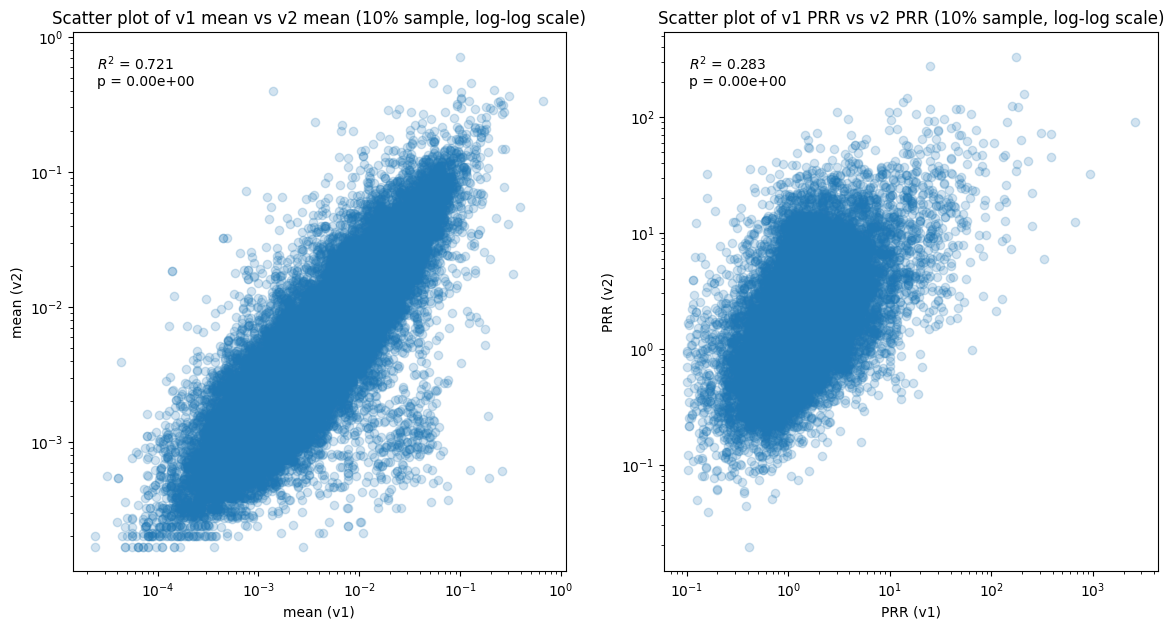

In [41]:
# metric = 'mean'
plt.figure(figsize=(14, 7))

for i, metric in enumerate(('mean', 'PRR')):

    keyv1 = f'{metric}_v1'
    keyv2 = f'{metric}_v2'

    # Sample 10% of the rows from merged_df and plot density with r2 and p-value
    sampled_df = merged_df.sample(frac=0.1, random_state=42)

    # Ensure PRR columns are numeric and handle non-numeric values
    sampled_df = sampled_df.copy()
    sampled_df[keyv1] = pandas.to_numeric(sampled_df[keyv1], errors='coerce')
    sampled_df[keyv2] = pandas.to_numeric(sampled_df[keyv2], errors='coerce')

    # Remove rows where PRR_v1 or PRR_v2 is missing or not positive (log10 not defined for <=0)
    mask = (sampled_df[keyv1] > 0) & (sampled_df[keyv2] > 0)

    plt.subplot(1, 2, i+1)
    plt.scatter(
        sampled_df[keyv1],
        sampled_df[keyv2],
        alpha=0.2
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(f'{metric} (v1)')
    plt.ylabel(f'{metric} (v2)')
    plt.title(f'Scatter plot of v1 {metric} vs v2 {metric} (10% sample, log-log scale)')

    # Compute r2 and p-value on log10-transformed values
    x = np.log10(sampled_df[keyv1].values)
    y = np.log10(sampled_df[keyv2].values)
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    # Annotate r2 and p-value
    plt.annotate(
        f"$R^2$ = {r_value**2:.3f}\np = {p_value:.2e}",
        xy=(0.05, 0.90), xycoords='axes fraction',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0)
    )

plt.show()


In [37]:
twosides_v1 = pandas.read_csv('../data/TWOSIDES.csv.gz')
twosides_v1.head()

/tmp/ipykernel_227669/256920723.py:1: DtypeWarning: Columns (0,2,4,6,7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  twosides_v1 = pandas.read_csv('../data/TWOSIDES.csv.gz')


,drug_1_rxnorn_id,drug_1_concept_name,drug_2_rxnorm_id,drug_2_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
0,10355,Temazepam,136411,sildenafil,10003239,Arthralgia,7,149,24,1536,2.91667,0.421275,0.0448718
1,1808,Bumetanide,7824,Oxytocin,10003239,Arthralgia,1,13,2,138,5.0,1.19224,0.0714286
2,221147,POLYETHYLENE GLYCOL 3350,5521,Hydroxychloroquine,10003239,Arthralgia,6,103,20,1070,3.0,0.454505,0.0550459
3,10324,Tamoxifen,8640,Prednisone,10012735,Diarrhoea,18,123,35,1375,5.14286,0.276271,0.12766
4,10355,Temazepam,136411,sildenafil,10012735,Diarrhoea,2,154,37,1523,0.540541,0.721093,0.0128205


In [42]:
twosides_v2 = pandas.read_csv('../results/2004-2009/two_hdpsm_nrep10_mratio5_maxsamp10000_pair_reaction_associations.csv')
twosides_v2.head()

,drug1,drug2,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI
0,isopropyl alcohol,paclitaxel,DYSPNOEA,All,5.0,3,3,3,27,9.0,5.0,0.400000
1,isopropyl alcohol,paclitaxel,DYSPNOEA,All,0.0,3,3,2,28,14.0,7.5,0.466974
2,isopropyl alcohol,paclitaxel,DYSPNOEA,All,1.0,3,3,3,27,9.0,5.0,0.400000
3,isopropyl alcohol,paclitaxel,DYSPNOEA,All,7.0,3,3,2,28,14.0,7.5,0.466974
4,isopropyl alcohol,paclitaxel,DYSPNOEA,All,4.0,3,3,2,28,14.0,7.5,0.466974


In [43]:
# Prepare lowercase columns for joining, similar to OFFSIDES above
twosides_v1 = twosides_v1.copy()
twosides_v2 = twosides_v2.copy()

twosides_v1['drug_1_concept_name_lower'] = twosides_v1['drug_1_concept_name'].str.lower()
twosides_v1['drug_2_concept_name_lower'] = twosides_v1['drug_2_concept_name'].str.lower()
twosides_v1['condition_concept_name_lower'] = twosides_v1['condition_concept_name'].str.lower()

twosides_v2['drug1_lower'] = twosides_v2['drug1'].str.lower()
twosides_v2['drug2_lower'] = twosides_v2['drug2'].str.lower()
twosides_v2['reaction_lower'] = twosides_v2['reaction'].str.lower()

# Join on lowercase drug1, drug2, and reaction/condition
twosides_merged = pandas.merge(
    twosides_v1,
    twosides_v2,
    left_on=['drug_1_concept_name_lower', 'drug_2_concept_name_lower', 'condition_concept_name_lower'],
    right_on=['drug1_lower', 'drug2_lower', 'reaction_lower'],
    how='inner',
    suffixes=('_v1', '_v2')
)

print(twosides_merged.shape)
print(twosides_merged.columns)


(2819005, 31)
Index(['drug_1_rxnorn_id', 'drug_1_concept_name', 'drug_2_rxnorm_id',
       'drug_2_concept_name', 'condition_meddra_id', 'condition_concept_name',
       'A', 'B', 'C', 'D', 'PRR_v1', 'PRR_error', 'mean_reporting_frequency',
       'drug_1_concept_name_lower', 'drug_2_concept_name_lower',
       'condition_concept_name_lower', 'drug1', 'drug2', 'reaction',
       'patient_sex', 'replicate', 'a', 'b', 'c', 'd', 'OR', 'PRR_v2', 'PHI',
       'drug1_lower', 'drug2_lower', 'reaction_lower'],
      dtype='object')


In [45]:
# Add mean columns to twosides_merged as for OFFSIDES above

# mean_v1: copy from 'mean_reporting_frequency' (from v1)
twosides_merged['mean_v1'] = twosides_merged['mean_reporting_frequency'].astype(float)

# mean_v2: compute as a/(a+b+c+d) using v2 columns
twosides_merged['mean_v2'] = twosides_merged['a'] / (twosides_merged['a'] + twosides_merged['b'])



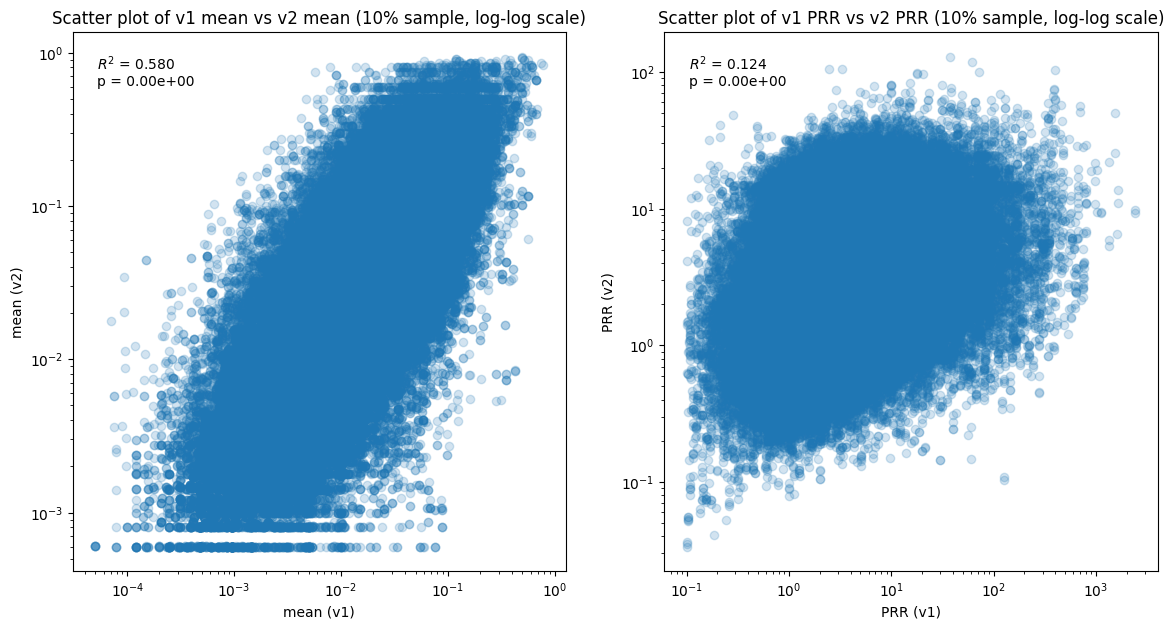

In [46]:
# metric = 'mean'
plt.figure(figsize=(14, 7))

for i, metric in enumerate(('mean', 'PRR')):

    keyv1 = f'{metric}_v1'
    keyv2 = f'{metric}_v2'

    # Sample 10% of the rows from merged_df and plot density with r2 and p-value
    sampled_df = twosides_merged.sample(frac=0.1, random_state=42)

    # Ensure PRR columns are numeric and handle non-numeric values
    sampled_df = sampled_df.copy()
    sampled_df[keyv1] = pandas.to_numeric(sampled_df[keyv1], errors='coerce')
    sampled_df[keyv2] = pandas.to_numeric(sampled_df[keyv2], errors='coerce')

    # Remove rows where PRR_v1 or PRR_v2 is missing or not positive (log10 not defined for <=0)
    mask = (sampled_df[keyv1] > 0) & (sampled_df[keyv2] > 0)

    plt.subplot(1, 2, i+1)
    plt.scatter(
        sampled_df[keyv1],
        sampled_df[keyv2],
        alpha=0.2
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(f'{metric} (v1)')
    plt.ylabel(f'{metric} (v2)')
    plt.title(f'Scatter plot of v1 {metric} vs v2 {metric} (10% sample, log-log scale)')

    # Compute r2 and p-value on log10-transformed values
    x = np.log10(sampled_df[keyv1].values)
    y = np.log10(sampled_df[keyv2].values)
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    # Annotate r2 and p-value
    plt.annotate(
        f"$R^2$ = {r_value**2:.3f}\np = {p_value:.2e}",
        xy=(0.05, 0.90), xycoords='axes fraction',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0)
    )

plt.show()
